# 03 Prescriptive Analytics: Loan Capital Allocation Optimisation with Linear Programming

This notebook is the prescriptive analytics component of the Home Credit Default Risk project. It builds on the predictive outputs from the previous scorecard model, but the main task here is not to keep improving prediction. The business question is:

> When lending capital and risk tolerance are limited, how much funding should Home Credit allocate to the low-risk and medium-risk customer groups in order to maximise expected profit?

This notebook uses a standard two-variable Linear Programming (LP) model. The model includes:

- Two decision variables: `x1` and `x2`
- A linear objective function: maximise portfolio expected profit
- Several linear constraints: budget constraint, expected-loss constraint, customer demand upper bounds, and non-negativity constraints
- Graphical method: plot constraint lines, feasible region, vertices, iso-profit lines, and the optimal solution
- Numerical validation: use `scipy.optimize.linprog` to verify the graphical and vertex-enumeration results
- What-if analysis: test how the optimal solution changes when budget, risk limit, interest rate, and LGD change

## Alignment with the marking rubric

According to the assignment requirements, this notebook emphasises the following points:

1. **Analytical integration**: predictive model outputs default probabilities, which then feed into prescriptive optimisation.
2. **Model selection and validation**: explain why LP is appropriate, and validate the ranking and calibration quality of the scorecard probabilities.
3. **Data-driven recommendations**: all capital-allocation recommendations come from model calculations rather than subjective judgement.
4. **Sensitivity analysis**: systematically change key business parameters and observe the impact on optimal allocations and profit.
5. **Business communication**: each mathematical symbol is linked to a business interpretation, and conclusions are written for management.


## 1. Business Background and Data Sources

Home Credit Default Risk is a credit-risk prediction project from Kaggle. The goal is to use customer application information, historical loan records, bureau records, POS/cash-loan balances, credit-card balances, and repayment history to predict whether an applicant may experience repayment difficulties.

The business context can be summarised as follows:

- Some Home Credit customers have limited traditional banking credit history.
- If the company is too conservative, it may reject customers who are able to repay and lose business opportunities.
- If the company is too aggressive, it may approve too many high-risk loans and increase default losses.
- Therefore, the predictive model answers "who is more likely to default", while prescriptive analytics answers "how resources should be allocated".

This notebook uses the following data sources:

- Local data description file: `dataset/数据集介绍.md`
- Kaggle competition page: `https://www.kaggle.com/competitions/home-credit-default-risk`
- Scorecard model and WOE data saved by the previous notebook: `dataset/processed/03/`
- Loan amount field from the original application table: `AMT_CREDIT` in `dataset/application_train.csv`

The Kaggle dataset does not provide actual contract interest rates, actual LGD, the bank's total lending budget, or its risk limit. Therefore, these variables cannot be read directly from the data. They must be set as business scenario assumptions and then tested through what-if analysis.


## 2. Analytical Framework

The logic of this notebook is:

```text
Scorecard model outputs raw default scores
        ↓
Probability calibration produces PD estimates closer to observed default rates
        ↓
Customers are segmented into low-, medium-, and high-risk groups by PD
        ↓
Estimate each investable group's average PD, total loan demand, and unit profit rate
        ↓
Build a two-variable linear programming model
        ↓
Plot constraint lines, feasible region, and the optimal point
        ↓
Solve the LP by vertex enumeration and linprog
        ↓
Run what-if sensitivity analysis
        ↓
Produce business recommendations, implementation plan, and limitations
```


## 3. Environment Setup and Data Loading


In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from scipy.optimize import linprog
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve
from sklearn.calibration import calibration_curve

# Font fallback. The notebook still runs if a font is unavailable.
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'Noto Sans CJK SC', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 120

BASE_DIR = os.getcwd()
PKL_DIR_03 = os.path.join(BASE_DIR, 'dataset', 'processed', '03')
OUT_DIR = os.path.join(BASE_DIR, 'dataset', 'processed', '04_lp_en')
os.makedirs(OUT_DIR, exist_ok=True)

print('Current working directory:', BASE_DIR)
print('Model input directory:', PKL_DIR_03)
print('Figure output directory:', OUT_DIR)

Current working directory: /Users/fanhongquan/Desktop/project 1 assignment 2
Model input directory: /Users/fanhongquan/Desktop/project 1 assignment 2/dataset/processed/03
Figure output directory: /Users/fanhongquan/Desktop/project 1 assignment 2/dataset/processed/04_lp_en


In [2]:
# Load saved scorecard model outputs from Notebook 02.
lr_model = joblib.load(os.path.join(PKL_DIR_03, 'lr_model.pkl'))
scaler = joblib.load(os.path.join(PKL_DIR_03, 'scaler.pkl'))
selected_features = joblib.load(os.path.join(PKL_DIR_03, 'selected_features.pkl'))
train_woe_final = joblib.load(os.path.join(PKL_DIR_03, 'train_woe_final.pkl'))
val_woe_final = joblib.load(os.path.join(PKL_DIR_03, 'val_woe_final.pkl'))

# AMT_CREDIT is read from the original application table to avoid loading very large processed checkpoints.
credit = pd.read_csv(
    os.path.join(BASE_DIR, 'dataset', 'application_train.csv'),
    usecols=['SK_ID_CURR', 'AMT_CREDIT']
)

print('Model and data loaded successfully')
print('selected_features:', len(selected_features))
print('train_woe_final:', train_woe_final.shape)
print('val_woe_final  :', val_woe_final.shape)
print('credit table   :', credit.shape)

Model and data loaded successfully
selected_features: 20
train_woe_final: (246008, 22)
val_woe_final  : (61503, 22)
credit table   : (307511, 2)


## 4. From Predictive Analytics to Prescriptive Analytics

The previous scorecard model already assigns each customer a default-risk score. Prescriptive analytics needs to transform that prediction result into decision inputs.

### 4.1 Why probability calibration is needed

The previous logistic regression model used `class_weight='balanced'`. This helps handle the small share of default observations, but it also means that `predict_proba` is more useful for ranking customers than for representing the true business default probability.

The LP model requires PD (Probability of Default) for profit and loss calculations. Therefore, this notebook applies a simple Platt calibration:

```text
raw score = logit(raw probability)
calibrated PD = sigmoid(a + b · raw score)
```

The calibration model is fitted on the training set and evaluated on the validation set. This does not change the customer risk ranking, but it makes the probability level closer to the observed default rate.


In [3]:
def predict_raw_pd(df):
    X = scaler.transform(df[selected_features])
    return lr_model.predict_proba(X)[:, 1]

def logit(p):
    p = np.clip(np.asarray(p), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p)).reshape(-1, 1)

def score_from_pd(p, base_score=600, pdo=50):
    p = np.clip(np.asarray(p), 1e-10, 1 - 1e-10)
    return base_score + pdo * np.log2((1 - p) / p)

raw_pd_train = predict_raw_pd(train_woe_final)
raw_pd_val = predict_raw_pd(val_woe_final)

calibrator = LogisticRegression(solver='lbfgs')
calibrator.fit(logit(raw_pd_train), train_woe_final['TARGET'])

cal_pd_train = calibrator.predict_proba(logit(raw_pd_train))[:, 1]
cal_pd_val = calibrator.predict_proba(logit(raw_pd_val))[:, 1]

validation_metrics = pd.DataFrame({
    'Metric': ['AUC', 'Brier Score', 'Mean Predicted PD', 'Actual Default Rate'],
    'Raw probability': [
        roc_auc_score(val_woe_final['TARGET'], raw_pd_val),
        brier_score_loss(val_woe_final['TARGET'], raw_pd_val),
        raw_pd_val.mean(),
        val_woe_final['TARGET'].mean()
    ],
    'Calibrated PD': [
        roc_auc_score(val_woe_final['TARGET'], cal_pd_val),
        brier_score_loss(val_woe_final['TARGET'], cal_pd_val),
        cal_pd_val.mean(),
        val_woe_final['TARGET'].mean()
    ]
})

validation_metrics

,Metric,Raw probability,Calibrated PD
0,AUC,0.762818,0.762818
1,Brier Score,0.197426,0.067746
2,Mean Predicted PD,0.412685,0.080202
3,Actual Default Rate,0.080728,0.080728


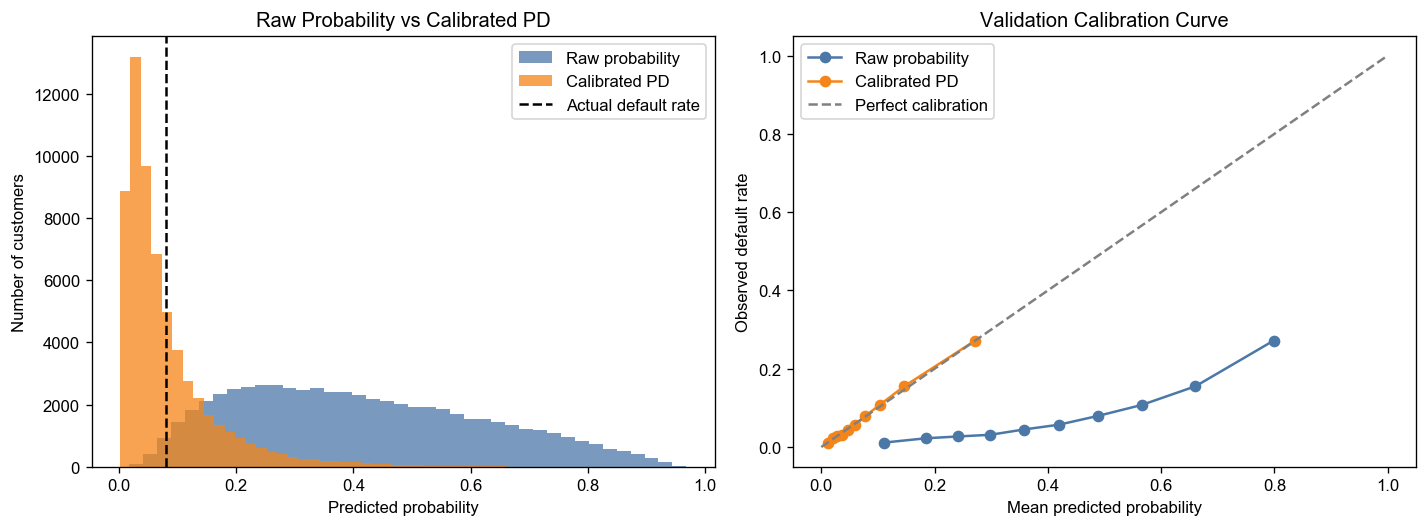

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(raw_pd_val, bins=40, alpha=0.75, label='Raw probability', color='#4C78A8')
axes[0].hist(cal_pd_val, bins=40, alpha=0.75, label='Calibrated PD', color='#F58518')
axes[0].axvline(val_woe_final['TARGET'].mean(), color='black', linestyle='--', linewidth=1.5, label='Actual default rate')
axes[0].set_title('Raw Probability vs Calibrated PD')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Number of customers')
axes[0].legend()

prob_true_raw, prob_pred_raw = calibration_curve(val_woe_final['TARGET'], raw_pd_val, n_bins=10, strategy='quantile')
prob_true_cal, prob_pred_cal = calibration_curve(val_woe_final['TARGET'], cal_pd_val, n_bins=10, strategy='quantile')
axes[1].plot(prob_pred_raw, prob_true_raw, marker='o', label='Raw probability', color='#4C78A8')
axes[1].plot(prob_pred_cal, prob_true_cal, marker='o', label='Calibrated PD', color='#F58518')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
axes[1].set_title('Validation Calibration Curve')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Observed default rate')
axes[1].legend()

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_01_probability_calibration.png'), bbox_inches='tight')
plt.show()

### 4.2 Building the Customer-Level Decision Table

The customer-level decision table contains the following fields:

- `SK_ID_CURR`: loan application ID from the Home Credit main table.
- `TARGET`: whether repayment difficulty actually occurred; used only for evaluation and interpretation.
- `raw_pd`: raw default probability directly output by the scorecard model.
- `p_default`: calibrated default probability used in the LP model.
- `score`: scorecard score converted from calibrated PD.
- `AMT_CREDIT`: requested or granted loan amount from `application_train.csv`.


In [5]:
all_woe = pd.concat([train_woe_final, val_woe_final], ignore_index=True)
raw_pd_all = predict_raw_pd(all_woe)
cal_pd_all = calibrator.predict_proba(logit(raw_pd_all))[:, 1]

customer_df = all_woe[['SK_ID_CURR', 'TARGET']].copy()
customer_df['raw_pd'] = raw_pd_all
customer_df['p_default'] = cal_pd_all
customer_df['score'] = score_from_pd(cal_pd_all)
customer_df = customer_df.merge(credit, on='SK_ID_CURR', how='left')

print('customer_df shape:', customer_df.shape)
print('Missing AMT_CREDIT:', customer_df['AMT_CREDIT'].isna().sum())
customer_df.head()

customer_df shape: (307511, 6)
Missing AMT_CREDIT: 0


,SK_ID_CURR,TARGET,raw_pd,p_default,score,AMT_CREDIT
0,310536,0,0.402932,0.056405,803.214090,227520.0
1,365516,0,0.565278,0.102410,756.585016,161730.0
2,242055,1,0.449271,0.067218,789.731344,728847.0
3,454894,1,0.451147,0.067688,789.192498,474183.0
4,448321,0,0.730304,0.190348,704.433112,254700.0


## 5. Business Parameter Assumptions and Risk Segmentation

### 5.1 Which variables come from the data?

The following variables come from the model or the dataset:

| Symbol | Name | Source | Meaning |
|---|---|---|---|
| $p_i$ | PD of customer $i$ | Calibrated scorecard output | Probability that the customer experiences repayment difficulty |
| $L_i$ | Loan amount of customer $i$ | `AMT_CREDIT` | Requested or granted loan amount |
| $D_1$ | Total demand of the low-risk group | Sum of `AMT_CREDIT` for low-risk customers | Maximum amount that can be lent to the low-risk group |
| $D_2$ | Total demand of the medium-risk group | Sum of `AMT_CREDIT` for medium-risk customers | Maximum amount that can be lent to the medium-risk group |
| $p_1$ | Average PD of the low-risk group | Loan-amount-weighted average | Unit loan risk of the low-risk group |
| $p_2$ | Average PD of the medium-risk group | Loan-amount-weighted average | Unit loan risk of the medium-risk group |

### 5.2 Which variables require business assumptions?

The Kaggle data does not include actual contract interest rates, recovery rates, capital budgets, or risk limits. Therefore, the following parameters are set as business scenario assumptions:

| Symbol | Default value | Business meaning | Rationale |
|---|---:|---|---|
| $r$ | 15% | Interest income per 1 unit of performing loan | Home Credit serves customers with higher risk and limited credit history; consumer-finance rates are usually higher than traditional bank loans. This project uses a moderately conservative portfolio return for teaching purposes. |
| $LGD$ | 45% | Final loss proportion per 1 unit of loan after default | The data does not contain recovery or collateral information; 45% is a common benchmark in credit-risk teaching and portfolio modelling. |
| $B$ | 120 billion | Total lending budget | A manageable share of total sample loan demand, used to simulate limited capital allocation. |
| $L$ | 2.1 billion | Maximum acceptable expected loss | Around 1.75% of the budget, representing a relatively prudent risk appetite. |

These parameters are not uniquely correct. The notebook therefore performs sensitivity analysis later to test whether the conclusion depends heavily on any single assumption.

### 5.3 Risk segmentation logic

First, calculate the break-even default probability:

$$
p_{break-even} = rac{r}{r + LGD}
$$

When the PD of a customer or segment is above this threshold:

$$
r(1-p) - LGD \cdot p < 0
$$

That means the expected profit per unit of loan is negative. Under the default assumptions:

$$
p_{break-even} = rac{0.15}{0.15 + 0.45} = 25\%
$$

Therefore, this notebook uses the following segmentation:

- **Low-risk group**: $p_i \le 5\%$. These customers have low default probability and are the first priority for lending.
- **Medium-risk group**: $5\% < p_i \le p_{break-even}$. These customers still have positive expected profit but higher risk.
- **High-risk group**: $p_i > p_{break-even}$. These customers have negative expected profit per unit of loan and are excluded from the LP lending pool.

> **Currency unit note**: The notebook keeps the original `AMT_CREDIT` currency units from the dataset. Terms such as "currency units" and "billion" are used for convenience and do not refer to a specific legal currency.


### 5.4 Model Assumptions Checklist

To align with the Seminar 6 assumption standard, this project groups key assumptions into four categories: data-based, predictive-output-based, managerial judgement, and simplification.

| Assumption | Type | Source / rationale | Impact if wrong | Sensitivity test |
|---|---|---|---|---|
| Calibrated `p_default` can represent customer PD | Predictive-output-based | Comes from the Notebook 02 scorecard and is calibrated in this notebook | If PD is biased upward or downward, segmentation and expected profit will shift | Predictive sensitivity and calibration curve |
| `AMT_CREDIT` represents lendable loan demand | Data-based | Loan amount field in the Kaggle main table | If actual approved amount is below requested amount, demand upper bounds are overstated | Budget and demand upper-bound constraints |
| Interest rate `r = 15%` | Managerial judgement | Contract rates are not available; uses a medium-return consumer-finance scenario | Affects break-even PD and unit profit rates | Interest-rate what-if scenarios |
| `LGD = 45%` | Managerial judgement / industry benchmark | Recovery rates are not available; uses a common credit-risk modelling benchmark | Affects expected loss and risk-limit usage | LGD what-if scenarios |
| Budget `B = 120B` | Managerial judgement | Simulates limited lending capital | If budget is too high or too low, the binding constraint may change | Budget what-if and RHS range of feasibility |
| Risk limit `L = 2.1B` | Managerial judgement | Represents a prudent risk appetite | It is the key bottleneck in the current LP | Shadow price and range of feasibility |
| The two risk segments can be represented by continuous amount variables | Simplification | Enables a two-dimensional graphical LP demonstration | Real approvals are customer-level discrete decisions | Limitation: future integer programming extension |


In [6]:
# Base-case business assumptions.
INTEREST_RATE = 0.15
LGD = 0.45
BUDGET = 120_000_000_000       # 120 billion
LOSS_LIMIT = 2_100_000_000     # 2.1 billion
LOW_RISK_THRESHOLD = 0.05

P_BREAKEVEN = INTEREST_RATE / (INTEREST_RATE + LGD)

print(f'Loan yield r                  : {INTEREST_RATE:.1%}')
print(f'Loss given default LGD        : {LGD:.1%}')
print(f'Break-even PD p_breakeven     : {P_BREAKEVEN:.1%}')
print(f'Low-risk threshold            : {LOW_RISK_THRESHOLD:.1%}')
print(f'Total budget B                : {BUDGET/1e9:.1f} billion')
print(f'Maximum expected loss L       : {LOSS_LIMIT/1e9:.1f} billion')

Loan yield r                  : 15.0%
Loss given default LGD        : 45.0%
Break-even PD p_breakeven     : 25.0%
Low-risk threshold            : 5.0%
Total budget B                : 120.0 billion
Maximum expected loss L       : 2.1 billion


In [7]:
def assign_segment(pd_value, low_threshold=LOW_RISK_THRESHOLD, p_breakeven=P_BREAKEVEN):
    if pd_value <= low_threshold:
        return 'Low-risk group'
    if pd_value <= p_breakeven:
        return 'Medium-risk group'
    return 'High-risk group / no lending'

customer_df['segment'] = customer_df['p_default'].apply(assign_segment)

segment_summary = (
    customer_df
    .groupby('segment')
    .agg(
        customers=('SK_ID_CURR', 'count'),
        total_credit=('AMT_CREDIT', 'sum'),
        avg_pd=('p_default', 'mean'),
        actual_default_rate=('TARGET', 'mean'),
        avg_score=('score', 'mean')
    )
    .reset_index()
)

# Loan-amount weighted PD is more appropriate for portfolio loss calculation.
weighted_pd = (
    customer_df
    .groupby('segment')
    .apply(lambda g: np.average(g['p_default'], weights=g['AMT_CREDIT']))
    .rename('weighted_pd')
    .reset_index()
)
segment_summary = segment_summary.merge(weighted_pd, on='segment')
segment_summary['expected_loss_rate'] = LGD * segment_summary['weighted_pd']
segment_summary['unit_profit_rate'] = INTEREST_RATE * (1 - segment_summary['weighted_pd']) - LGD * segment_summary['weighted_pd']

segment_summary_display = segment_summary.copy()
for col in ['total_credit']:
    segment_summary_display[col] = segment_summary_display[col] / 1e9
segment_summary_display.rename(columns={'total_credit': 'total_credit_billion'}, inplace=True)
segment_summary_display

,segment,customers,total_credit_billion,avg_pd,actual_default_rate,avg_score,weighted_pd,expected_loss_rate,unit_profit_rate
0,High-risk group / no lending,14694,6.585334,0.341053,0.331768,648.691528,0.337978,0.152090,-0.052787
1,Low-risk group,145461,97.339303,0.027404,0.025966,866.210986,0.026553,0.011949,0.134068
2,Medium-risk group,147356,80.282447,0.107226,0.109755,759.797800,0.104009,0.046804,0.087594


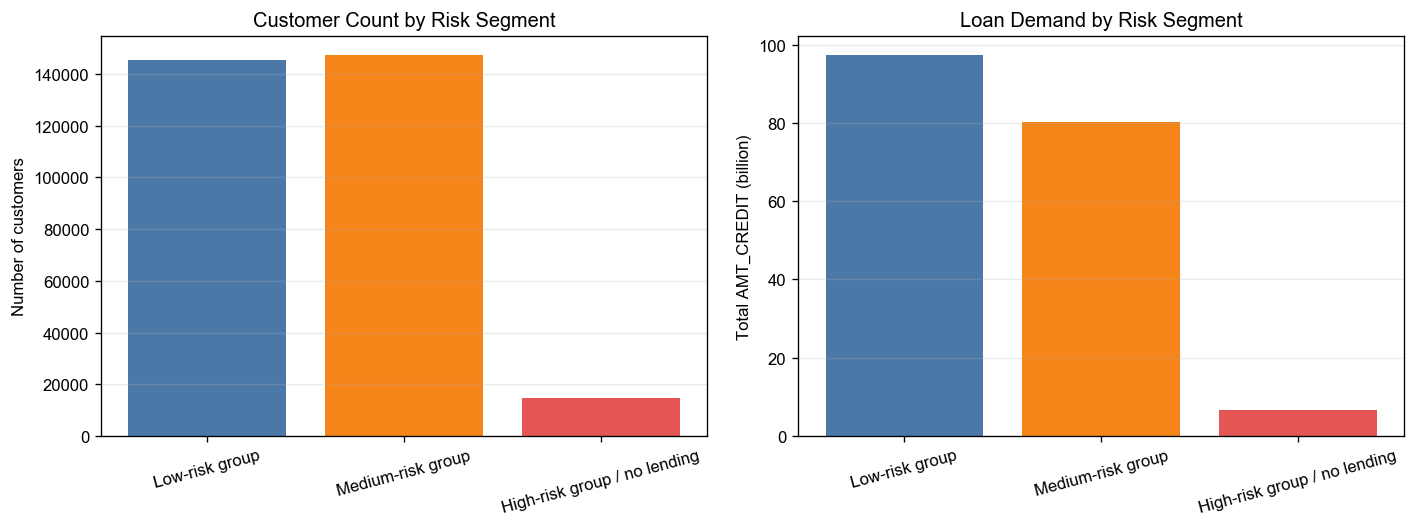

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

order = ['Low-risk group', 'Medium-risk group', 'High-risk group / no lending']
colors = ['#4C78A8', '#F58518', '#E45756']
plot_df = segment_summary.set_index('segment').loc[order].reset_index()

axes[0].bar(plot_df['segment'], plot_df['customers'], color=colors)
axes[0].set_title('Customer Count by Risk Segment')
axes[0].set_ylabel('Number of customers')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(plot_df['segment'], plot_df['total_credit'] / 1e9, color=colors)
axes[1].set_title('Loan Demand by Risk Segment')
axes[1].set_ylabel('Total AMT_CREDIT (billion)')
axes[1].tick_params(axis='x', rotation=15)

for ax in axes:
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_02_risk_segments.png'), bbox_inches='tight')
plt.show()

## 6. Linear Programming Model Definition

### 6.1 Decision variables

The model has two decision variables:

$$
x_1 = 	ext{loan amount allocated to the low-risk customer group}
$$

$$
x_2 = 	ext{loan amount allocated to the medium-risk customer group}
$$

The unit is the dataset's currency unit. For plotting, later charts show amounts in billions.

### 6.2 Segment parameters

For the low-risk and medium-risk groups, define:

| Symbol | Meaning | Source |
|---|---|---|
| $p_1$ | Loan-amount-weighted average PD of the low-risk group | Calculated from customer-level `p_default` and `AMT_CREDIT` |
| $p_2$ | Loan-amount-weighted average PD of the medium-risk group | Calculated from customer-level `p_default` and `AMT_CREDIT` |
| $D_1$ | Maximum loan demand of the low-risk group | Total `AMT_CREDIT` for the low-risk group |
| $D_2$ | Maximum loan demand of the medium-risk group | Total `AMT_CREDIT` for the medium-risk group |
| $\pi_1$ | Expected profit rate per unit of low-risk lending | $r(1-p_1)-LGD \cdot p_1$ |
| $\pi_2$ | Expected profit rate per unit of medium-risk lending | $r(1-p_2)-LGD \cdot p_2$ |

### 6.3 Expected profit per unit of loan

If a segment has average PD $p$, then for each 1 unit of lending:

- With probability $1-p$, the borrower does not default and generates interest income $r$.
- With probability $p$, the borrower defaults and creates loss $LGD$.

Therefore, the expected profit rate per unit of loan is:

$$
\pi = r(1-p) - LGD \cdot p
$$

### 6.4 Full LP formulation

$$
\max Z = \pi_1 x_1 + \pi_2 x_2
$$

subject to:

$$
x_1 + x_2 \le B \quad 	ext{(budget constraint)}
$$

$$
LGD \cdot p_1 x_1 + LGD \cdot p_2 x_2 \le L \quad 	ext{(expected-loss constraint)}
$$

$$
x_1 \le D_1 \quad 	ext{(low-risk demand upper bound)}
$$

$$
x_2 \le D_2 \quad 	ext{(medium-risk demand upper bound)}
$$

$$
x_1, x_2 \ge 0 \quad 	ext{(non-negativity constraints)}
$$

This is a standard linear programming problem because all expressions use only first-order terms in $x_1$ and $x_2$. There are no squared terms, products between decision variables, logarithms, or other non-linear terms.


In [9]:
def get_lp_parameters(df, r=INTEREST_RATE, lgd=LGD, low_threshold=LOW_RISK_THRESHOLD):
    p_breakeven = r / (r + lgd)
    low = df[df['p_default'] <= low_threshold].copy()
    medium = df[(df['p_default'] > low_threshold) & (df['p_default'] <= p_breakeven)].copy()
    high = df[df['p_default'] > p_breakeven].copy()

    if low.empty or medium.empty:
        raise ValueError('The low-risk or medium-risk group is empty, so the two-variable LP cannot be built.')

    p1 = np.average(low['p_default'], weights=low['AMT_CREDIT'])
    p2 = np.average(medium['p_default'], weights=medium['AMT_CREDIT'])
    D1 = low['AMT_CREDIT'].sum()
    D2 = medium['AMT_CREDIT'].sum()
    pi1 = r * (1 - p1) - lgd * p1
    pi2 = r * (1 - p2) - lgd * p2

    return {
        'r': r,
        'lgd': lgd,
        'p_breakeven': p_breakeven,
        'low_threshold': low_threshold,
        'p1': p1,
        'p2': p2,
        'D1': D1,
        'D2': D2,
        'pi1': pi1,
        'pi2': pi2,
        'n_low': len(low),
        'n_medium': len(medium),
        'n_high': len(high)
    }

params = get_lp_parameters(customer_df)

lp_parameter_table = pd.DataFrame({
    'Symbol': ['p1', 'p2', 'D1', 'D2', 'pi1', 'pi2', 'LGD*p1', 'LGD*p2'],
    'Meaning': [
        'Loan-amount-weighted average PD of low-risk group',
        'Loan-amount-weighted average PD of medium-risk group',
        'Maximum loan demand of low-risk group',
        'Maximum loan demand of medium-risk group',
        'Expected profit rate per unit of low-risk lending',
        'Expected profit rate per unit of medium-risk lending',
        'Expected loss rate per unit of low-risk lending',
        'Expected loss rate per unit of medium-risk lending'
    ],
    'Value': [
        params['p1'], params['p2'], params['D1'], params['D2'],
        params['pi1'], params['pi2'], LGD * params['p1'], LGD * params['p2']
    ]
})

lp_parameter_table_display = lp_parameter_table.copy()
lp_parameter_table_display['Value'] = [
    f'{params["p1"]:.2%}',
    f'{params["p2"]:.2%}',
    f'{params["D1"]/1e9:,.2f} billion',
    f'{params["D2"]/1e9:,.2f} billion',
    f'{params["pi1"]:.2%}',
    f'{params["pi2"]:.2%}',
    f'{LGD * params["p1"]:.2%}',
    f'{LGD * params["p2"]:.2%}'
]
lp_parameter_table_display

,Symbol,Meaning,Value
0,p1,Loan-amount-weighted average PD of low-risk group,2.66%
1,p2,Loan-amount-weighted average PD of medium-risk...,10.40%
2,D1,Maximum loan demand of low-risk group,97.34 billion
3,D2,Maximum loan demand of medium-risk group,80.28 billion
4,pi1,Expected profit rate per unit of low-risk lending,13.41%
5,pi2,Expected profit rate per unit of medium-risk l...,8.76%
6,LGD*p1,Expected loss rate per unit of low-risk lending,1.19%
7,LGD*p2,Expected loss rate per unit of medium-risk len...,4.68%


## 7. Solving the LP: Vertex Enumeration and `linprog` Validation

A two-variable linear program can be explained with the graphical method and vertex enumeration.

The key theorem is: if a linear program has an optimal solution, at least one optimal solution occurs at a vertex of the feasible region.

Therefore, this section first lists all feasible-region vertices, calculates the objective value at each vertex, and then uses `scipy.optimize.linprog` for validation.


In [10]:
def build_lp_matrices(params, budget=BUDGET, loss_limit=LOSS_LIMIT):
    p1, p2 = params['p1'], params['p2']
    D1, D2 = params['D1'], params['D2']
    pi1, pi2 = params['pi1'], params['pi2']
    lgd = params['lgd']

    # linprog minimizes, so maximize profit by minimizing negative profit.
    c = np.array([-pi1, -pi2])
    A_ub = np.array([
        [1, 1],
        [lgd * p1, lgd * p2],
        [1, 0],
        [0, 1]
    ])
    b_ub = np.array([budget, loss_limit, D1, D2])
    bounds = [(0, None), (0, None)]
    return c, A_ub, b_ub, bounds

def solve_lp(params, budget=BUDGET, loss_limit=LOSS_LIMIT):
    c, A_ub, b_ub, bounds = build_lp_matrices(params, budget, loss_limit)
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    if not res.success:
        return {
            'success': False,
            'message': res.message,
            'x1': np.nan,
            'x2': np.nan,
            'profit': np.nan,
            'expected_loss': np.nan,
            'budget_used': np.nan
        }
    x1, x2 = res.x
    return {
        'success': True,
        'message': res.message,
        'x1': x1,
        'x2': x2,
        'profit': params['pi1'] * x1 + params['pi2'] * x2,
        'expected_loss': params['lgd'] * params['p1'] * x1 + params['lgd'] * params['p2'] * x2,
        'budget_used': x1 + x2
    }

def enumerate_vertices(params, budget=BUDGET, loss_limit=LOSS_LIMIT, tol=1e-6):
    c, A_ub, b_ub, bounds = build_lp_matrices(params, budget, loss_limit)

    # Boundaries are a_i x = b_i plus x1 = 0 and x2 = 0.
    lines = []
    names = ['Budget constraint', 'Expected-loss constraint', 'Low-risk demand upper bound', 'Medium-risk demand upper bound']
    for name, a, b in zip(names, A_ub, b_ub):
        lines.append((name, a.astype(float), float(b)))
    lines.append(('x1 = 0', np.array([1.0, 0.0]), 0.0))
    lines.append(('x2 = 0', np.array([0.0, 1.0]), 0.0))

    vertices = []
    for i in range(len(lines)):
        for j in range(i + 1, len(lines)):
            name_i, a_i, b_i = lines[i]
            name_j, a_j, b_j = lines[j]
            A = np.vstack([a_i, a_j])
            b = np.array([b_i, b_j])
            if abs(np.linalg.det(A)) < 1e-12:
                continue
            x = np.linalg.solve(A, b)
            if np.all(x >= -tol) and np.all(A_ub @ x <= b_ub + 1e-2):
                x = np.maximum(x, 0)
                vertices.append({
                    'x1': x[0],
                    'x2': x[1],
                    'binding_lines': f'{name_i} & {name_j}'
                })

    # Remove duplicates.
    unique = []
    for v in vertices:
        if not any(np.allclose([v['x1'], v['x2']], [u['x1'], u['x2']], rtol=0, atol=1e-2) for u in unique):
            unique.append(v)

    vertex_df = pd.DataFrame(unique)
    vertex_df['expected_profit'] = params['pi1'] * vertex_df['x1'] + params['pi2'] * vertex_df['x2']
    vertex_df['expected_loss'] = params['lgd'] * params['p1'] * vertex_df['x1'] + params['lgd'] * params['p2'] * vertex_df['x2']
    vertex_df['budget_used'] = vertex_df['x1'] + vertex_df['x2']
    vertex_df = vertex_df.sort_values('expected_profit', ascending=False).reset_index(drop=True)
    return vertex_df

solution = solve_lp(params)
vertices = enumerate_vertices(params)

vertices_display = vertices.copy()
for col in ['x1', 'x2', 'expected_profit', 'expected_loss', 'budget_used']:
    vertices_display[col] = vertices_display[col] / 1e9
vertices_display.rename(columns={
    'x1': 'x1_low_risk_billion',
    'x2': 'x2_medium_risk_billion',
    'expected_profit': 'expected_profit_billion',
    'expected_loss': 'expected_loss_billion',
    'budget_used': 'budget_used_billion'
}, inplace=True)
vertices_display

,x1_low_risk_billion,x2_medium_risk_billion,binding_lines,expected_profit_billion,expected_loss_billion,budget_used_billion
0,97.339303,20.017809,Expected-loss constraint & Low-risk demand upp...,14.803567,2.100000,117.357112
1,97.339303,0.000000,Low-risk demand upper bound & x2 = 0,13.050117,1.163084,97.339303
2,0.000000,44.867824,Expected-loss constraint & x1 = 0,3.930174,2.100000,44.867824
3,0.000000,0.000000,x1 = 0 & x2 = 0,0.000000,0.000000,0.000000


In [11]:
solution_table = pd.DataFrame({
    'Item': [
        'Optimal x1: low-risk allocation',
        'Optimal x2: medium-risk allocation',
        'Total budget used',
        'Expected loss',
        'Expected profit',
        'Solver status'
    ],
    'Value': [
        f'{solution["x1"]/1e9:,.2f} billion',
        f'{solution["x2"]/1e9:,.2f} billion',
        f'{solution["budget_used"]/1e9:,.2f} billion',
        f'{solution["expected_loss"]/1e9:,.2f} billion',
        f'{solution["profit"]/1e9:,.2f} billion',
        solution['message']
    ]
})
solution_table

,Item,Value
0,Optimal x1: low-risk allocation,97.34 billion
1,Optimal x2: medium-risk allocation,20.02 billion
2,Total budget used,117.36 billion
3,Expected loss,2.10 billion
4,Expected profit,14.80 billion
5,Solver status,Optimization terminated successfully. (HiGHS S...


## 8. Graphical Method: Feasible Region, Constraint Lines, and Optimal Solution

Because this model has only two decision variables, it can be explained with a two-dimensional chart:

- Horizontal axis: $x_1$, the loan amount allocated to the low-risk group.
- Vertical axis: $x_2$, the loan amount allocated to the medium-risk group.
- Shaded area: all feasible solutions satisfying the constraints.
- Red star: the optimal solution that maximises expected profit.
- Dashed lines: iso-profit lines; moving further up and to the right represents higher profit.


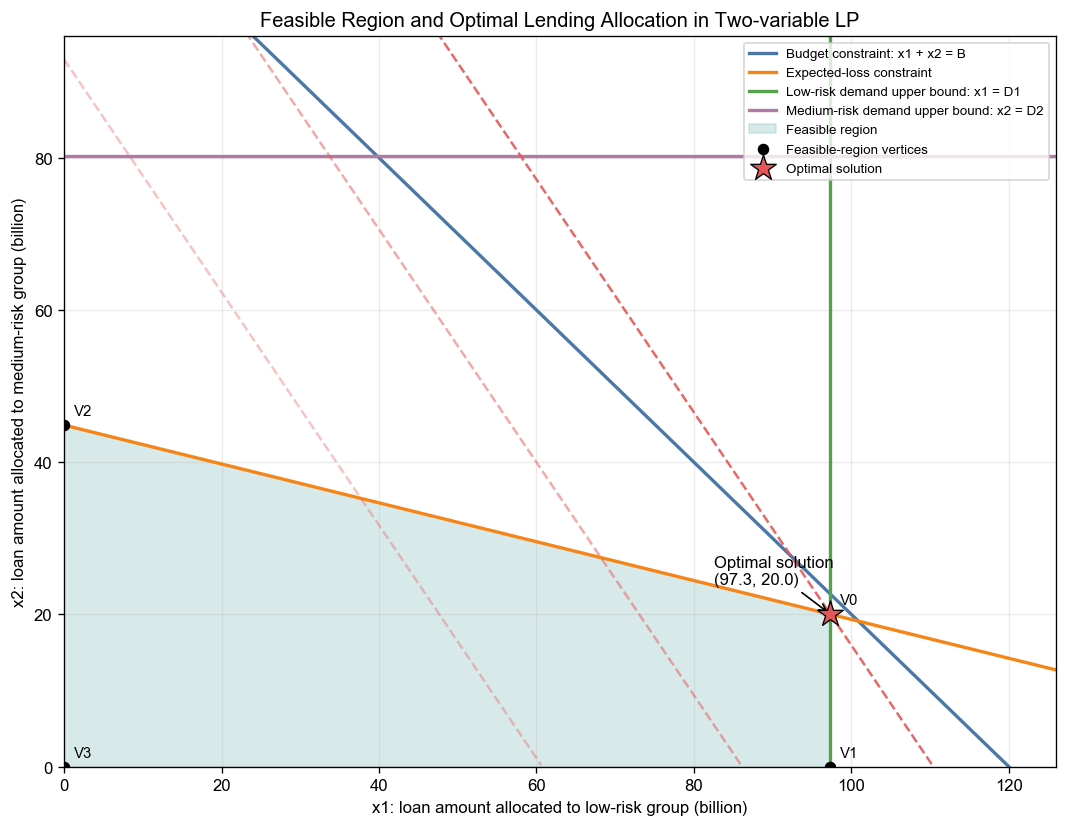

In [12]:
def plot_feasible_region(params, budget=BUDGET, loss_limit=LOSS_LIMIT, solution=None):
    p1, p2 = params['p1'], params['p2']
    D1, D2 = params['D1'], params['D2']
    pi1, pi2 = params['pi1'], params['pi2']
    lgd = params['lgd']

    vertices = enumerate_vertices(params, budget, loss_limit)
    pts = vertices[['x1', 'x2']].values
    center = pts.mean(axis=0)
    angles = np.arctan2(pts[:, 1] - center[1], pts[:, 0] - center[0])
    pts_sorted = pts[np.argsort(angles)]

    x_max = max(D1, budget) * 1.05
    x = np.linspace(0, x_max, 500)

    fig, ax = plt.subplots(figsize=(9, 7))

    # Constraint lines.
    ax.plot(x / 1e9, (budget - x) / 1e9, label='Budget constraint: x1 + x2 = B', color='#4C78A8', linewidth=2)
    ax.plot(x / 1e9, (loss_limit - lgd * p1 * x) / (lgd * p2) / 1e9,
            label='Expected-loss constraint', color='#F58518', linewidth=2)
    ax.axvline(D1 / 1e9, label='Low-risk demand upper bound: x1 = D1', color='#54A24B', linewidth=2)
    ax.axhline(D2 / 1e9, label='Medium-risk demand upper bound: x2 = D2', color='#B279A2', linewidth=2)

    # Feasible region.
    ax.fill(pts_sorted[:, 0] / 1e9, pts_sorted[:, 1] / 1e9, color='#72B7B2', alpha=0.28, label='Feasible region')
    ax.scatter(vertices['x1'] / 1e9, vertices['x2'] / 1e9, color='black', s=35, zorder=5, label='Feasible-region vertices')

    for idx, row in vertices.iterrows():
        ax.annotate(
            f'V{idx}',
            (row['x1'] / 1e9, row['x2'] / 1e9),
            textcoords='offset points', xytext=(6, 6), fontsize=9
        )

    # Objective function iso-profit lines.
    if solution is not None and solution['success']:
        z_star = solution['profit']
        for frac, alpha in [(0.55, 0.35), (0.78, 0.5), (1.0, 0.9)]:
            z = z_star * frac
            y = (z - pi1 * x) / pi2
            mask = y >= 0
            ax.plot(x[mask] / 1e9, y[mask] / 1e9, linestyle='--', color='#E45756', alpha=alpha)

        ax.scatter(solution['x1'] / 1e9, solution['x2'] / 1e9,
                   marker='*', s=260, color='#E45756', edgecolor='black', linewidth=0.8,
                   zorder=8, label='Optimal solution')
        ax.annotate(
            f'Optimal solution\n({solution["x1"]/1e9:.1f}, {solution["x2"]/1e9:.1f})',
            (solution['x1'] / 1e9, solution['x2'] / 1e9),
            textcoords='offset points', xytext=(-70, 18), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='black', lw=1)
        )

    ax.set_xlim(0, x_max / 1e9)
    ax.set_ylim(0, max(D2, budget) / 1e9 * 0.8)
    ax.set_xlabel('x1: loan amount allocated to low-risk group (billion)')
    ax.set_ylabel('x2: loan amount allocated to medium-risk group (billion)')
    ax.set_title('Feasible Region and Optimal Lending Allocation in Two-variable LP')
    ax.grid(alpha=0.25)
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, 'fig_03_lp_feasible_region.png'), bbox_inches='tight')
    plt.show()

plot_feasible_region(params, solution=solution)

## 9. Business Interpretation of the Optimal Solution

The LP solution shows that:

- The low-risk group should receive lending capital first because it has a higher unit expected profit rate and a lower unit expected loss.
- After the low-risk group demand upper bound is reached, remaining capital can be allocated to the medium-risk group.
- Under the default scenario, the risk constraint limits the amount allocated to the medium-risk group, so the optimal solution does not necessarily use the full budget.

This demonstrates the value of prescriptive analytics: the model does not only identify who is risky; it also tells management how to allocate capital under limited resources and risk appetite.


In [13]:
def binding_constraints(params, sol, budget=BUDGET, loss_limit=LOSS_LIMIT, tol=1e-3):
    checks = pd.DataFrame({
        'Constraint': [
            'Budget constraint x1 + x2 <= B',
            'Expected-loss constraint LGD*p1*x1 + LGD*p2*x2 <= L',
            'Low-risk demand upper bound x1 <= D1',
            'Medium-risk demand upper bound x2 <= D2'
        ],
        'Left hand side': [
            sol['budget_used'],
            sol['expected_loss'],
            sol['x1'],
            sol['x2']
        ],
        'Right hand side': [
            budget,
            loss_limit,
            params['D1'],
            params['D2']
        ]
    })
    checks['Slack'] = checks['Right hand side'] - checks['Left hand side']
    checks['Binding?'] = checks['Slack'].abs() <= np.maximum(1, checks['Right hand side']) * tol
    return checks

binding_table = binding_constraints(params, solution)
binding_display = binding_table.copy()
for col in ['Left hand side', 'Right hand side', 'Slack']:
    binding_display[col] = binding_display[col] / 1e9
binding_display.rename(columns={
    'Left hand side': 'Left hand side (billion)',
    'Right hand side': 'Right hand side (billion)',
    'Slack': 'Slack (billion)'
}, inplace=True)
binding_display

,Constraint,Left hand side (billion),Right hand side (billion),Slack (billion),Binding?
0,Budget constraint x1 + x2 <= B,117.357112,120.000000,2.642888,False
1,Expected-loss constraint LGD*p1*x1 + LGD*p2*x2...,2.100000,2.100000,0.000000,True
2,Low-risk demand upper bound x1 <= D1,97.339303,97.339303,0.000000,True
3,Medium-risk demand upper bound x2 <= D2,20.017809,80.282447,60.264638,False


## 10. What-if Sensitivity Analysis

The marking rubric requires prescriptive analytics to provide more than a single optimal solution. It also needs to explain whether the recommendation is robust when key parameters change.

This section tests four types of scenarios:

1. **Budget changes**: How does the optimal allocation change if available lending capital increases or decreases?
2. **Risk-limit changes**: How do profit and lending volume change if management tightens or relaxes risk appetite?
3. **Interest-rate changes**: How do break-even PD, segmentation, and the optimal solution change when loan yield changes?
4. **LGD changes**: If the economic environment worsens and default loss severity rises, is the recommended strategy still feasible?


In [14]:
def scenario_solution(r=INTEREST_RATE, lgd=LGD, budget=BUDGET, loss_limit=LOSS_LIMIT, low_threshold=LOW_RISK_THRESHOLD):
    p = get_lp_parameters(customer_df, r=r, lgd=lgd, low_threshold=low_threshold)
    sol = solve_lp(p, budget=budget, loss_limit=loss_limit)
    return {
        'r': r,
        'LGD': lgd,
        'budget_billion': budget / 1e9,
        'loss_limit_billion': loss_limit / 1e9,
        'p_breakeven': p['p_breakeven'],
        'p1': p['p1'],
        'p2': p['p2'],
        'D1_billion': p['D1'] / 1e9,
        'D2_billion': p['D2'] / 1e9,
        'x1_billion': sol['x1'] / 1e9,
        'x2_billion': sol['x2'] / 1e9,
        'budget_used_billion': sol['budget_used'] / 1e9,
        'expected_loss_billion': sol['expected_loss'] / 1e9,
        'expected_profit_billion': sol['profit'] / 1e9,
        'success': sol['success']
    }

scenarios = []

for budget in [80e9, 100e9, 120e9, 140e9, 160e9]:
    scenarios.append({'Scenario': f'Budget {budget/1e9:.0f}B', 'Type': 'Budget', **scenario_solution(budget=budget)})

for loss_limit in [1.5e9, 1.8e9, 2.1e9, 2.4e9, 2.7e9]:
    scenarios.append({'Scenario': f'Risk limit {loss_limit/1e9:.1f}B', 'Type': 'Loss limit', **scenario_solution(loss_limit=loss_limit)})

for r in [0.12, 0.15, 0.18, 0.20]:
    scenarios.append({'Scenario': f'Interest rate {r:.0%}', 'Type': 'Interest rate', **scenario_solution(r=r)})

for lgd in [0.35, 0.45, 0.55, 0.60]:
    scenarios.append({'Scenario': f'LGD {lgd:.0%}', 'Type': 'LGD', **scenario_solution(lgd=lgd)})

# The low-/medium-risk segmentation threshold is a managerial assumption, so test whether the optimal solution is robust to this cutoff.
for lt in [0.03, 0.05, 0.08]:
    scenarios.append({'Scenario': f'Low-risk cutoff {lt:.0%}', 'Type': 'Low-risk cutoff', **scenario_solution(low_threshold=lt)})

scenario_df = pd.DataFrame(scenarios)
scenario_df.head(10)

,Scenario,Type,r,LGD,budget_billion,loss_limit_billion,p_breakeven,p1,p2,D1_billion,D2_billion,x1_billion,x2_billion,budget_used_billion,expected_loss_billion,expected_profit_billion,success
0,Budget 80B,Budget,0.15,0.45,80.0,2.1,0.25,0.026553,0.104009,97.339303,80.282447,80.000000,0.000000,80.000000,0.955901,10.725466,True
1,Budget 100B,Budget,0.15,0.45,100.0,2.1,0.25,0.026553,0.104009,97.339303,80.282447,97.339303,2.660697,100.000000,1.287615,13.283180,True
2,Budget 120B,Budget,0.15,0.45,120.0,2.1,0.25,0.026553,0.104009,97.339303,80.282447,97.339303,20.017809,117.357112,2.100000,14.803567,True
3,Budget 140B,Budget,0.15,0.45,140.0,2.1,0.25,0.026553,0.104009,97.339303,80.282447,97.339303,20.017809,117.357112,2.100000,14.803567,True
4,Budget 160B,Budget,0.15,0.45,160.0,2.1,0.25,0.026553,0.104009,97.339303,80.282447,97.339303,20.017809,117.357112,2.100000,14.803567,True
5,Risk limit 1.5B,Loss limit,0.15,0.45,120.0,1.5,0.25,0.026553,0.104009,97.339303,80.282447,97.339303,7.198431,104.537734,1.500000,13.680660,True
6,Risk limit 1.8B,Loss limit,0.15,0.45,120.0,1.8,0.25,0.026553,0.104009,97.339303,80.282447,97.339303,13.608120,110.947423,1.800000,14.242113,True
7,Risk limit 2.1B,Loss limit,0.15,0.45,120.0,2.1,0.25,0.026553,0.104009,97.339303,80.282447,97.339303,20.017809,117.357112,2.100000,14.803567,True
8,Risk limit 2.4B,Loss limit,0.15,0.45,120.0,2.4,0.25,0.026553,0.104009,97.339303,80.282447,97.339303,22.660697,120.000000,2.223698,15.035069,True
9,Risk limit 2.7B,Loss limit,0.15,0.45,120.0,2.7,0.25,0.026553,0.104009,97.339303,80.282447,97.339303,22.660697,120.000000,2.223698,15.035069,True


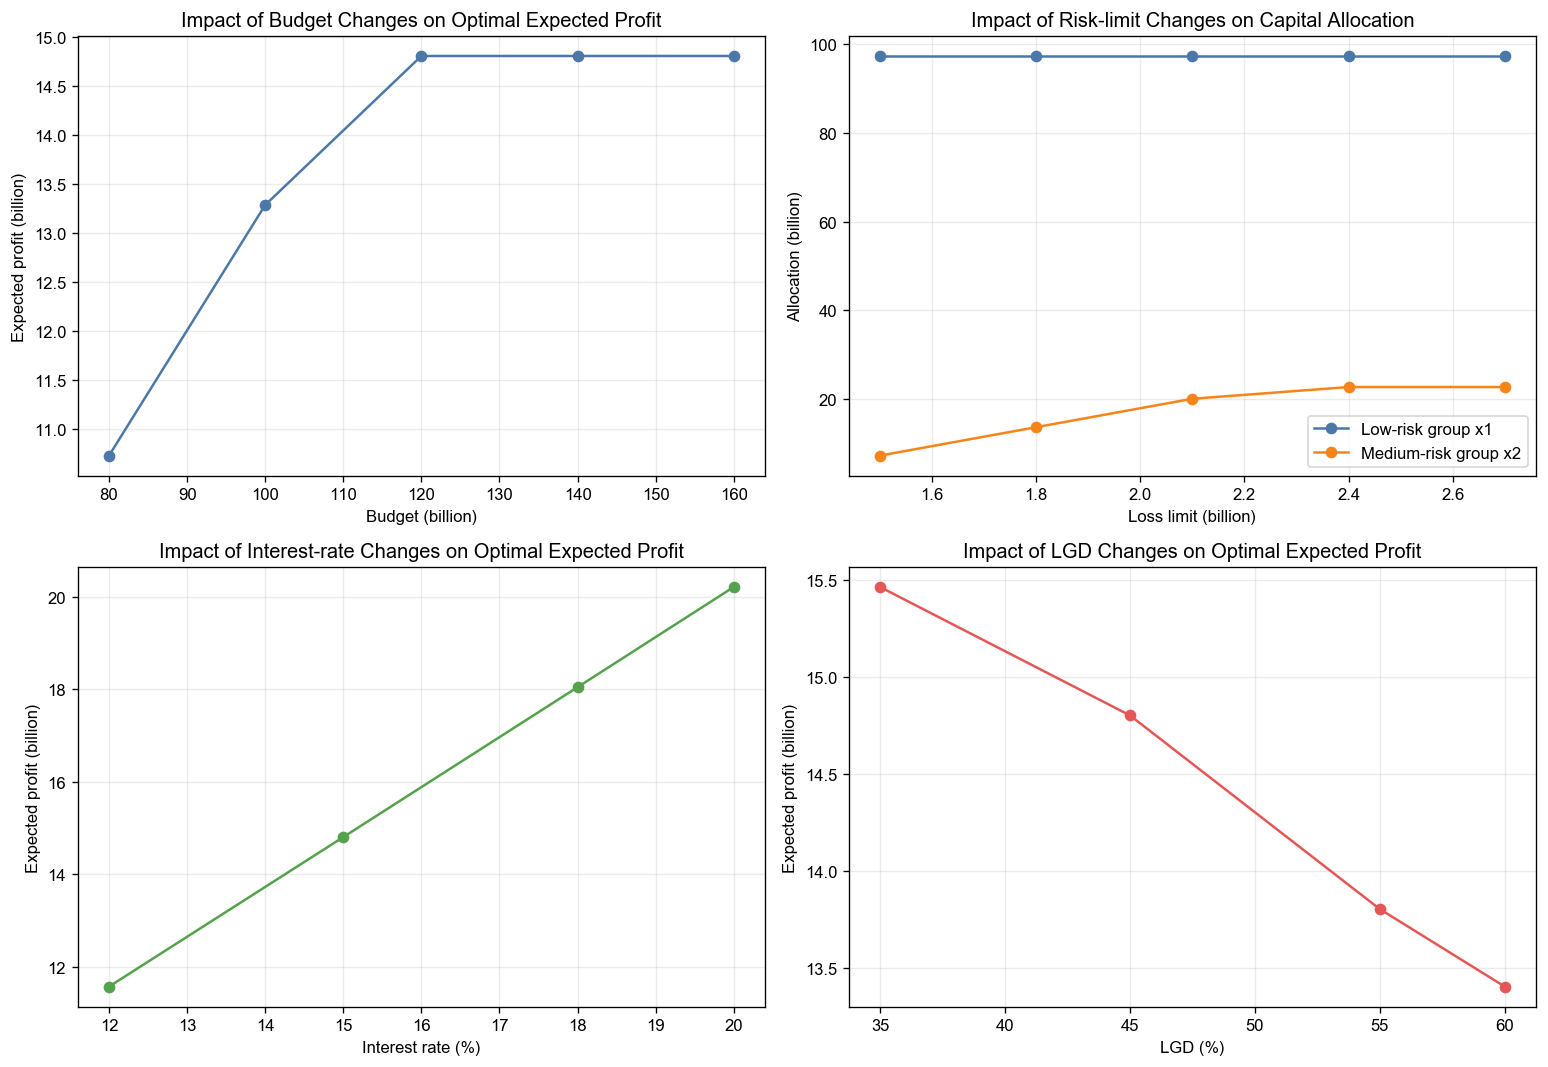

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Budget scenarios.
budget_df = scenario_df[scenario_df['Type'] == 'Budget'].sort_values('budget_billion')
axes[0, 0].plot(budget_df['budget_billion'], budget_df['expected_profit_billion'], marker='o', color='#4C78A8')
axes[0, 0].set_title('Impact of Budget Changes on Optimal Expected Profit')
axes[0, 0].set_xlabel('Budget (billion)')
axes[0, 0].set_ylabel('Expected profit (billion)')
axes[0, 0].grid(alpha=0.25)

# Loss limit scenarios.
loss_df = scenario_df[scenario_df['Type'] == 'Loss limit'].sort_values('loss_limit_billion')
axes[0, 1].plot(loss_df['loss_limit_billion'], loss_df['x1_billion'], marker='o', label='Low-risk group x1', color='#4C78A8')
axes[0, 1].plot(loss_df['loss_limit_billion'], loss_df['x2_billion'], marker='o', label='Medium-risk group x2', color='#F58518')
axes[0, 1].set_title('Impact of Risk-limit Changes on Capital Allocation')
axes[0, 1].set_xlabel('Loss limit (billion)')
axes[0, 1].set_ylabel('Allocation (billion)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.25)

# Interest-rate scenarios.
rate_df = scenario_df[scenario_df['Type'] == 'Interest rate'].sort_values('r')
axes[1, 0].plot(rate_df['r'] * 100, rate_df['expected_profit_billion'], marker='o', label='Expected profit', color='#54A24B')
axes[1, 0].set_title('Impact of Interest-rate Changes on Optimal Expected Profit')
axes[1, 0].set_xlabel('Interest rate (%)')
axes[1, 0].set_ylabel('Expected profit (billion)')
axes[1, 0].grid(alpha=0.25)

# LGD scenarios.
lgd_df = scenario_df[scenario_df['Type'] == 'LGD'].sort_values('LGD')
axes[1, 1].plot(lgd_df['LGD'] * 100, lgd_df['expected_profit_billion'], marker='o', color='#E45756')
axes[1, 1].set_title('Impact of LGD Changes on Optimal Expected Profit')
axes[1, 1].set_xlabel('LGD (%)')
axes[1, 1].set_ylabel('Expected profit (billion)')
axes[1, 1].grid(alpha=0.25)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_04_sensitivity_analysis.png'), bbox_inches='tight')
plt.show()

In [16]:
scenario_display = scenario_df[[
    'Scenario', 'Type', 'p_breakeven', 'x1_billion', 'x2_billion',
    'budget_used_billion', 'expected_loss_billion', 'expected_profit_billion'
]].copy()

for col in ['p_breakeven']:
    scenario_display[col] = scenario_display[col].map(lambda x: f'{x:.1%}')
for col in ['x1_billion', 'x2_billion', 'budget_used_billion', 'expected_loss_billion', 'expected_profit_billion']:
    scenario_display[col] = scenario_display[col].map(lambda x: f'{x:,.2f}')

scenario_display

,Scenario,Type,p_breakeven,x1_billion,x2_billion,budget_used_billion,expected_loss_billion,expected_profit_billion
0,Budget 80B,Budget,25.0%,80.00,0.00,80.00,0.96,10.73
1,Budget 100B,Budget,25.0%,97.34,2.66,100.00,1.29,13.28
2,Budget 120B,Budget,25.0%,97.34,20.02,117.36,2.10,14.80
3,Budget 140B,Budget,25.0%,97.34,20.02,117.36,2.10,14.80
4,Budget 160B,Budget,25.0%,97.34,20.02,117.36,2.10,14.80
5,Risk limit 1.5B,Loss limit,25.0%,97.34,7.20,104.54,1.50,13.68
6,Risk limit 1.8B,Loss limit,25.0%,97.34,13.61,110.95,1.80,14.24
7,Risk limit 2.1B,Loss limit,25.0%,97.34,20.02,117.36,2.10,14.80
8,Risk limit 2.4B,Loss limit,25.0%,97.34,22.66,120.00,2.22,15.04
9,Risk limit 2.7B,Loss limit,25.0%,97.34,22.66,120.00,2.22,15.04


## 11. Predictive Model Sensitivity: Scorecard Parameter Sensitivity

Topic 7 emphasises that sensitivity analysis applies not only to the LP model but also to the predictive model. If a key predictive-model parameter is poorly chosen, it can affect the inputs to the prescriptive analytics model. Therefore, the stability of the prediction results must be checked.

The predictive model in this project is a logistic regression scorecard. One of the most important tunable parameters in logistic regression is regularisation strength `C`:

- Smaller `C` means stronger regularisation, a simpler model, and possible **underfitting**.
- Larger `C` means weaker regularisation, a more complex model, and possible **overfitting** or unstable probabilities.
- A reasonable `C` is not necessarily the one with the highest validation AUC; it should balance predictive performance and robustness.

This section retrains the logistic regression scorecard with different `C` values and compares:

- training AUC
- validation AUC
- AUC gap, or the performance difference between training and validation
- calibrated validation Brier Score

If the training AUC increases clearly but validation AUC does not improve, the extra model complexity does not improve generalisation and may indicate overfitting risk.


In [17]:

# Predictive model sensitivity: tune the regularisation parameter C.
# This uses the same selected WOE features and class_weight setting as the original scorecard model.

C_values = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0]

X_train_scaled = scaler.transform(train_woe_final[selected_features])
X_val_scaled = scaler.transform(val_woe_final[selected_features])
y_train = train_woe_final['TARGET'].values
y_val = val_woe_final['TARGET'].values

sensitivity_rows = []

for C in C_values:
    candidate_model = LogisticRegression(
        C=C,
        class_weight='balanced',
        max_iter=1000,
        solver='lbfgs',
        n_jobs=-1,
        random_state=42
    )
    candidate_model.fit(X_train_scaled, y_train)

    raw_train = candidate_model.predict_proba(X_train_scaled)[:, 1]
    raw_val = candidate_model.predict_proba(X_val_scaled)[:, 1]

    # Calibrate each candidate so Brier scores are comparable as probability estimates.
    candidate_calibrator = LogisticRegression(solver='lbfgs')
    candidate_calibrator.fit(logit(raw_train), y_train)
    cal_train = candidate_calibrator.predict_proba(logit(raw_train))[:, 1]
    cal_val = candidate_calibrator.predict_proba(logit(raw_val))[:, 1]

    train_auc = roc_auc_score(y_train, raw_train)
    val_auc = roc_auc_score(y_val, raw_val)

    sensitivity_rows.append({
        'C': C,
        'train_auc': train_auc,
        'val_auc': val_auc,
        'auc_gap': train_auc - val_auc,
        'train_brier_calibrated': brier_score_loss(y_train, cal_train),
        'val_brier_calibrated': brier_score_loss(y_val, cal_val),
        'mean_val_pd_calibrated': cal_val.mean()
    })

predictive_sensitivity = pd.DataFrame(sensitivity_rows)

# A simple robustness score: high validation AUC, low train-validation gap, low calibrated Brier score.
predictive_sensitivity['robustness_score'] = (
    predictive_sensitivity['val_auc']
    - 0.5 * predictive_sensitivity['auc_gap'].abs()
    - 0.2 * predictive_sensitivity['val_brier_calibrated']
)

predictive_sensitivity_display = predictive_sensitivity.copy()
for col in ['train_auc', 'val_auc', 'auc_gap', 'train_brier_calibrated', 'val_brier_calibrated', 'mean_val_pd_calibrated', 'robustness_score']:
    predictive_sensitivity_display[col] = predictive_sensitivity_display[col].map(lambda x: f'{x:.4f}')

predictive_sensitivity_display


,C,train_auc,val_auc,auc_gap,train_brier_calibrated,val_brier_calibrated,mean_val_pd_calibrated,robustness_score
0,0.001,0.7624,0.7628,-0.0004,0.0679,0.0677,0.0802,0.7491
1,0.003,0.7624,0.7628,-0.0004,0.0679,0.0677,0.0802,0.7491
2,0.010,0.7624,0.7628,-0.0004,0.0679,0.0677,0.0802,0.7491
3,0.030,0.7624,0.7628,-0.0004,0.0679,0.0677,0.0802,0.7491
4,0.100,0.7624,0.7628,-0.0004,0.0679,0.0677,0.0802,0.7491
5,0.300,0.7624,0.7628,-0.0004,0.0679,0.0677,0.0802,0.7491
6,1.000,0.7624,0.7628,-0.0004,0.0679,0.0677,0.0802,0.7491


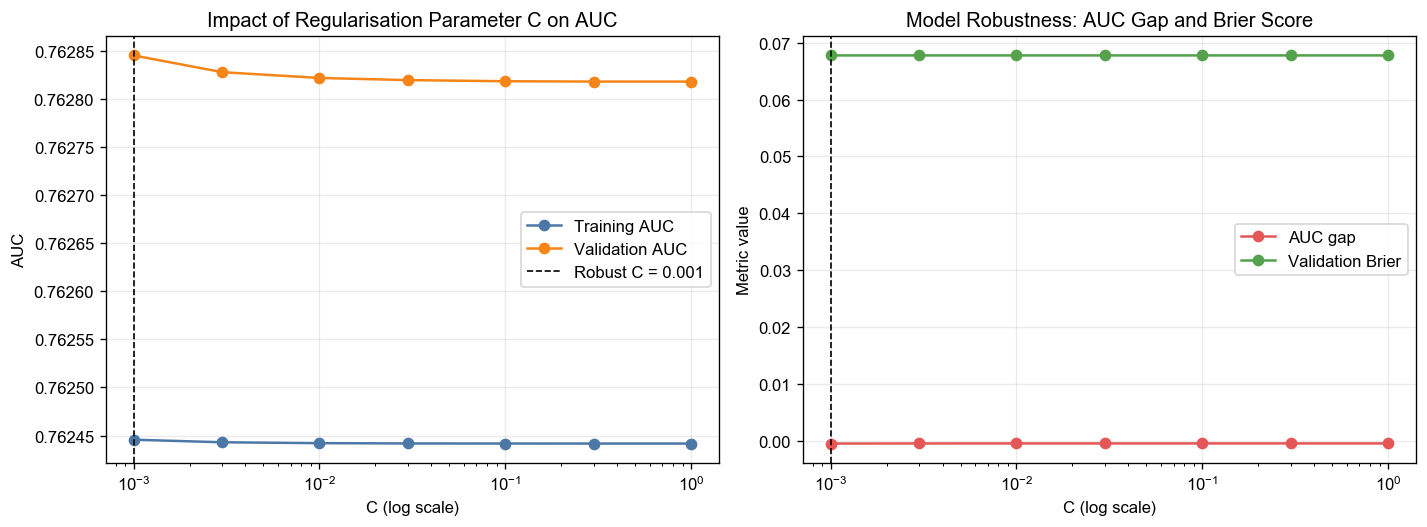

C with highest robustness score: 0.001
Corresponding validation AUC: 0.7628
Corresponding AUC gap       : -0.0004
Corresponding validation Brier: 0.0677


In [18]:

best_row = predictive_sensitivity.loc[predictive_sensitivity['robustness_score'].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(predictive_sensitivity['C'], predictive_sensitivity['train_auc'], marker='o', label='Training AUC', color='#4C78A8')
axes[0].plot(predictive_sensitivity['C'], predictive_sensitivity['val_auc'], marker='o', label='Validation AUC', color='#F58518')
axes[0].axvline(best_row['C'], linestyle='--', color='black', linewidth=1, label=f'Robust C = {best_row["C"]}')
axes[0].set_xscale('log')
axes[0].set_title('Impact of Regularisation Parameter C on AUC')
axes[0].set_xlabel('C (log scale)')
axes[0].set_ylabel('AUC')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(predictive_sensitivity['C'], predictive_sensitivity['auc_gap'], marker='o', label='AUC gap', color='#E45756')
axes[1].plot(predictive_sensitivity['C'], predictive_sensitivity['val_brier_calibrated'], marker='o', label='Validation Brier', color='#54A24B')
axes[1].axvline(best_row['C'], linestyle='--', color='black', linewidth=1)
axes[1].set_xscale('log')
axes[1].set_title('Model Robustness: AUC Gap and Brier Score')
axes[1].set_xlabel('C (log scale)')
axes[1].set_ylabel('Metric value')
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_05_predictive_sensitivity.png'), bbox_inches='tight')
plt.show()

print(f'C with highest robustness score: {best_row["C"]}')
print(f'Corresponding validation AUC: {best_row["val_auc"]:.4f}')
print(f'Corresponding AUC gap       : {best_row["auc_gap"]:.4f}')
print(f'Corresponding validation Brier: {best_row["val_brier_calibrated"]:.4f}')


### 11.1 Predictive Sensitivity Interpretation

From the predictive-model sensitivity perspective, this project focuses on stability rather than a single best score.

- If `C` is too small, regularisation is too strong and the model may not fully use the WOE features, causing underfitting.
- If `C` is too large, regularisation is too weak. Training performance may rise slightly, but if validation performance does not improve, the generalisation benefit is limited.
- If several `C` values have very similar validation AUC, the better choice is the one with a smaller AUC gap and lower Brier score.

This aligns with Topic 7: parameter selection should consider robustness as well as predictive performance. Since the LP later uses calibrated PD, the stability of predicted probabilities directly affects risk segmentation, unit profit rates, and optimal capital allocation.


## 12. Prescriptive Model Sensitivity: Solver-style Sensitivity Analysis

Topic 7 requires prescriptive sensitivity analysis to go beyond ordinary what-if scenarios and explain concepts similar to an Excel Solver Sensitivity Report.

This section analyses two key elements:

1. **Objective coefficient**: unit expected profit rates `π1` and `π2`. They determine how much expected profit is generated by lending 1 unit to the low-risk or medium-risk group.
2. **Constraint RHS**: budget upper bound `B` and maximum expected loss limit `L`. They represent available capital and risk tolerance.

The sensitivity-report concepts to explain are:

- **Range of Optimality**: the range within which objective-function coefficients can change while the current optimal-solution structure remains optimal.
- **Range of Feasibility**: the range within which constraint RHS values can change while the current shadow price remains valid.
- **Shadow Price / Dual Value**: the maximum improvement in the objective value when a constraint RHS increases by 1 unit.

The binding constraints in the current optimal solution are:

- Low-risk demand upper bound `x1 = D1`
- Expected-loss constraint `LGD · p1 · x1 + LGD · p2 · x2 = L`

The budget constraint is not binding in the default solution, so its shadow price is 0.


In [19]:

def solver_style_sensitivity(params, sol, budget=BUDGET, loss_limit=LOSS_LIMIT):
    pi1, pi2 = params['pi1'], params['pi2']
    a1, a2 = params['lgd'] * params['p1'], params['lgd'] * params['p2']
    D1, D2 = params['D1'], params['D2']
    x1, x2 = sol['x1'], sol['x2']

    # Objective coefficient ranges based on current active vertex: x1 = D1 and risk constraint binding.
    # Current point stays optimal if the objective slope remains between adjacent binding edges.
    pi1_lower = pi2 * a1 / a2
    pi1_upper = np.inf
    pi2_lower = 0.0
    pi2_upper = pi1 * a2 / a1

    objective_report = pd.DataFrame([
        {
            'Coefficient': 'π1: low-risk unit profit',
            'Current value': pi1,
            'Allowable decrease': pi1 - pi1_lower,
            'Allowable increase': np.inf,
            'Lower bound': pi1_lower,
            'Upper bound': np.inf,
            'Business meaning': 'As long as the low-risk unit profit rate does not fall below this lower bound, prioritising the low-risk group remains optimal.'
        },
        {
            'Coefficient': 'π2: medium-risk unit profit',
            'Current value': pi2,
            'Allowable decrease': pi2 - pi2_lower,
            'Allowable increase': pi2_upper - pi2,
            'Lower bound': pi2_lower,
            'Upper bound': pi2_upper,
            'Business meaning': 'The medium-risk unit profit rate can vary within this range while the current optimal vertex remains optimal.'
        }
    ])

    # RHS range for expected loss limit L.
    # With x1 fixed at D1, x2 = (L - a1*D1)/a2.
    # Basis remains valid when 0 <= x2 <= min(D2, B - D1).
    L_lower = a1 * D1
    L_upper = a1 * D1 + a2 * min(D2, budget - D1)
    shadow_L = pi2 / a2

    # RHS range for budget B.
    # Budget is non-binding, so the solution stays unchanged as long as B >= x1 + x2.
    B_lower = x1 + x2
    B_upper = np.inf
    shadow_B = 0.0

    rhs_report = pd.DataFrame([
        {
            'Constraint RHS': 'B: total lending budget',
            'Current RHS': budget,
            'Allowable decrease': budget - B_lower,
            'Allowable increase': np.inf,
            'Lower bound': B_lower,
            'Upper bound': np.inf,
            'Shadow price': shadow_B,
            'Business meaning': 'The default solution does not use the full budget; if budget stays above current usage, extra budget will not improve profit.'
        },
        {
            'Constraint RHS': 'L: expected loss limit',
            'Current RHS': loss_limit,
            'Allowable decrease': loss_limit - L_lower,
            'Allowable increase': L_upper - loss_limit,
            'Lower bound': L_lower,
            'Upper bound': L_upper,
            'Shadow price': shadow_L,
            'Business meaning': 'The risk limit is the key bottleneck; within the valid range, each extra unit of expected-loss allowance increases optimal expected profit by approximately the shadow price.'
        }
    ])

    return objective_report, rhs_report

objective_report, rhs_report = solver_style_sensitivity(params, solution)

objective_display = objective_report.copy()
for col in ['Current value', 'Allowable decrease', 'Allowable increase', 'Lower bound', 'Upper bound']:
    objective_display[col] = objective_display[col].map(lambda x: 'Infinity' if np.isinf(x) else f'{x:.4%}')

rhs_display = rhs_report.copy()
for col in ['Current RHS', 'Allowable decrease', 'Allowable increase', 'Lower bound', 'Upper bound']:
    rhs_display[col] = rhs_display[col].map(lambda x: 'Infinity' if np.isinf(x) else f'{x/1e9:,.3f} billion')
rhs_display['Shadow price'] = rhs_display['Shadow price'].map(lambda x: f'{x:.4f}')

print('Range of Optimality - Objective Coefficients')
display(objective_display)

print('Range of Feasibility and Shadow Price - Constraint RHS')
display(rhs_display)


Range of Optimality - Objective Coefficients


,Coefficient,Current value,Allowable decrease,Allowable increase,Lower bound,Upper bound,Business meaning
0,π1: low-risk unit profit,13.4068%,11.1706%,Infinity,2.2362%,Infinity,As long as the low-risk unit profit rate does ...
1,π2: medium-risk unit profit,8.7594%,8.7594%,43.7561%,0.0000%,52.5155%,The medium-risk unit profit rate can vary with...


Range of Feasibility and Shadow Price - Constraint RHS


,Constraint RHS,Current RHS,Allowable decrease,Allowable increase,Lower bound,Upper bound,Shadow price,Business meaning
0,B: total lending budget,120.000 billion,2.643 billion,Infinity,117.357 billion,Infinity,0.0000,The default solution does not use the full bud...
1,L: expected loss limit,2.100 billion,0.937 billion,0.124 billion,1.163 billion,2.224 billion,1.8715,The risk limit is the key bottleneck; within t...


### 12.2 Solver Dual-Value Cross-check (Shadow Price Validation)

The Range of Optimality, Range of Feasibility, and Shadow Price above are manually derived from the current optimal vertex. To strengthen validation, this section directly reads the dual values (`ineqlin.marginals`) from `scipy.optimize.linprog` and compares them with the hand-derived shadow price. If they match, the hand calculation is consistent with the solver and is credible.


In [20]:
# Solver dual-value cross-check: use linprog marginals to validate the hand-derived shadow price.
c_obj, A_ub, b_ub, bounds = build_lp_matrices(params)
res_dual = linprog(c_obj, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

# For A_ub x <= b_ub constraints, linprog marginals are non-positive, so the shadow price is their negative value.
solver_shadow = -res_dual.ineqlin.marginals
constraint_names = ['Budget constraint B', 'Expected-loss constraint L', 'Low-risk demand upper bound D1', 'Medium-risk demand upper bound D2']

shadow_L_hand = params['pi2'] / (params['lgd'] * params['p2'])  # Hand calculation: shadow price of L = pi2 / (LGD*p2)
hand_shadow = ['0 (non-binding)', f'{shadow_L_hand:.4f}', '(binding, see linprog)', '0 (non-binding)']

dual_check = pd.DataFrame({
    'Constraint': constraint_names,
    'linprog shadow price': [f'{v:.4f}' for v in solver_shadow],
    'Hand-derived shadow price': hand_shadow
})
print('Cross-check between linprog dual values (shadow prices) and hand calculation:')
display(dual_check)

print(f'\nShadow price of risk limit L: hand calculation = {shadow_L_hand:.4f}, linprog = {solver_shadow[1]:.4f}')
if abs(shadow_L_hand - solver_shadow[1]) < 1e-4:
    print('Consistent: the hand-derived Range of Feasibility / Shadow Price matches the solver dual value.')
else:
    print('Inconsistent: please check the constraint settings.')
print(f'Shadow price of budget B: linprog = {solver_shadow[0]:.4f} (approximately 0, confirming that the budget is non-binding).')

Cross-check between linprog dual values (shadow prices) and hand calculation:


,Constraint,linprog shadow price,Hand-derived shadow price
0,Budget constraint B,0.0000,0 (non-binding)
1,Expected-loss constraint L,1.8715,1.8715
2,Low-risk demand upper bound D1,0.1117,"(binding, see linprog)"
3,Medium-risk demand upper bound D2,0.0000,0 (non-binding)



Shadow price of risk limit L: hand calculation = 1.8715, linprog = 1.8715
Consistent: the hand-derived Range of Feasibility / Shadow Price matches the solver dual value.
Shadow price of budget B: linprog = 0.0000 (approximately 0, confirming that the budget is non-binding).


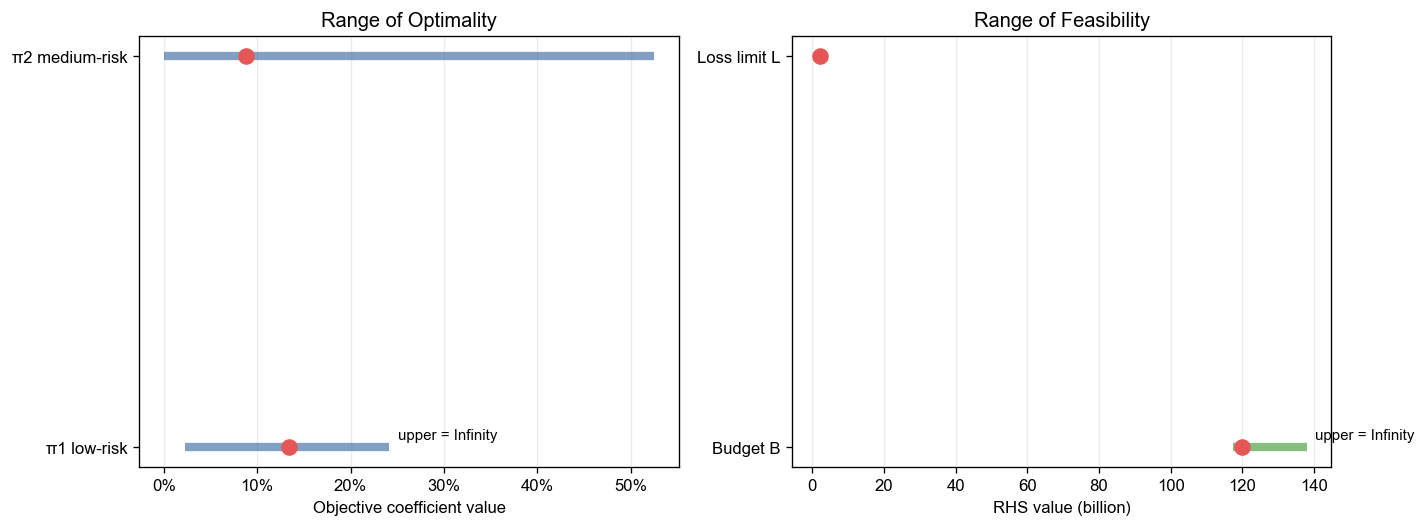

In [21]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Objective coefficient ranges.
obj_plot = objective_report.copy()
labels = ['π1 low-risk', 'π2 medium-risk']
current = obj_plot['Current value'].values
lower = obj_plot['Lower bound'].replace(np.inf, np.nan).values
upper = obj_plot['Upper bound'].replace(np.inf, np.nan).values

for i, label in enumerate(labels):
    left = lower[i]
    right = upper[i] if not np.isnan(upper[i]) else current[i] * 1.8
    axes[0].hlines(i, left, right, color='#4C78A8', linewidth=5, alpha=0.7)
    axes[0].scatter(current[i], i, color='#E45756', s=80, zorder=3)
    if np.isnan(upper[i]):
        axes[0].annotate('upper = Infinity', (right, i), textcoords='offset points', xytext=(5, 5), fontsize=9)

axes[0].set_yticks(range(len(labels)))
axes[0].set_yticklabels(labels)
axes[0].set_xlabel('Objective coefficient value')
axes[0].set_title('Range of Optimality')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].grid(axis='x', alpha=0.25)

# RHS ranges.
rhs_plot = rhs_report.copy()
rhs_labels = ['Budget B', 'Loss limit L']
current_rhs = rhs_plot['Current RHS'].values / 1e9
lower_rhs = rhs_plot['Lower bound'].replace(np.inf, np.nan).values / 1e9
upper_rhs = rhs_plot['Upper bound'].replace(np.inf, np.nan).values / 1e9

for i, label in enumerate(rhs_labels):
    left = lower_rhs[i]
    right = upper_rhs[i] if not np.isnan(upper_rhs[i]) else current_rhs[i] * 1.15
    axes[1].hlines(i, left, right, color='#54A24B', linewidth=5, alpha=0.7)
    axes[1].scatter(current_rhs[i], i, color='#E45756', s=80, zorder=3)
    if np.isnan(upper_rhs[i]):
        axes[1].annotate('upper = Infinity', (right, i), textcoords='offset points', xytext=(5, 5), fontsize=9)

axes[1].set_yticks(range(len(rhs_labels)))
axes[1].set_yticklabels(rhs_labels)
axes[1].set_xlabel('RHS value (billion)')
axes[1].set_title('Range of Feasibility')
axes[1].grid(axis='x', alpha=0.25)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_06_solver_sensitivity_ranges.png'), bbox_inches='tight')
plt.show()


### 12.1 Solver-style Sensitivity Interpretation

This section corresponds to the Topic 7 prescriptive model sensitivity standard.

**Range of Optimality** describes the stable range of objective-function coefficients:

- If `π1` or `π2` changes within the allowable range, the current optimal vertex remains optimal.
- If `π2` falls below the lower bound, the marginal value of medium-risk lending decreases and the model tends to reduce or eliminate medium-risk allocation.
- If `π2` rises above the upper bound, the medium-risk group becomes too attractive relative to the low-risk group, and the optimal-solution structure may shift toward more medium-risk lending.

**Range of Feasibility** describes the stable range of constraint RHS values:

- Budget `B` is not currently a binding constraint, so increasing budget does not improve the objective value. The optimal solution only changes if the budget falls below the current used amount.
- Risk limit `L` is currently a binding constraint, so it is the main bottleneck. As long as `L` changes within the valid range, the shadow price can be used to estimate the change in profit.

**Shadow Price** has the following business meaning:

- The shadow price of `B` is 0, so extra budget currently has no marginal value.
- The shadow price of `L` is positive, so relaxing the risk limit can increase optimal expected profit within the current range.

This is closer to an Excel Solver sensitivity report than ordinary what-if analysis. It also addresses the robustness requirement: within which parameter ranges is the current strategy still defensible, and which parameter is the main bottleneck?


## 13. Management Recommendations

Based on the default scenario and sensitivity analysis, the following business recommendations can be made.

### 13.1 Capital allocation recommendations

1. **Prioritise fully serving the low-risk customer group**. The low-risk group has lower PD, lower unit expected loss, and higher unit expected profit, so it should be the first priority.
2. **Use the medium-risk group as the marginal lending pool**. After low-risk demand is met, capital can be allocated to the medium-risk group, but the amount should be controlled by the expected-loss constraint.
3. **Exclude the high-risk group from the capital-allocation model**. The high-risk group exceeds the break-even PD and has negative expected profit per unit of loan, so it should not be part of routine lending allocation.

### 13.2 Risk management recommendations

1. **Use PD thresholds and risk limits together as a policy**. A single approval threshold is not enough; the company also needs portfolio-level budget and expected-loss limits.
2. **Recalibrate PD regularly**. The scorecard's ranking ability may remain stable, but actual default rates change with the economic environment, so PD calibration should be updated regularly.
3. **Create a portfolio quota for the medium-risk group**. Medium-risk customers should not all be rejected; they should be selectively approved within the available risk limit.

### 13.3 Expected business value

- Reallocate capital away from negative-expected-profit customers toward positive-expected-profit customers while keeping risk controlled.
- Use an explainable LP model to connect predictions with management actions and improve decision transparency.
- Use sensitivity analysis to help management understand how budget, risk appetite, and economic conditions affect the recommended strategy.


## 14. Change Management Plan

To turn the LP result into an actual credit policy, the following implementation plan can be used.

### 14.1 Affected stakeholders

- **Risk management team**: responsible for PD model monitoring, calibration, and risk-limit setting.
- **Credit approval team**: executes approval strategy according to risk segments and quota pools.
- **Finance and treasury team**: provides the lending budget and capital constraints.
- **Senior management**: decides risk appetite, profit targets, and policy boundaries.
- **Compliance team**: checks model usage, customer fairness, and explainability.

### 14.2 Implementation steps

1. **Pilot stage**: first apply the LP allocation policy to selected loan products or regions.
2. **Monitoring stage**: monitor actual default rate, approval rate, profit, and loss every month.
3. **Calibration stage**: recalibrate model probabilities if actual default rates deviate from predicted PD.
4. **Expansion stage**: once the pilot is stable, extend the LP quota pool to more product lines.
5. **Governance stage**: establish model approval, parameter update, exception alert, and manual review processes.

### 14.3 Reducing implementation risk

- Keep a manual review channel to avoid automatically rejecting all borderline customers.
- Separately assess high-risk customers who have special collateral or additional information.
- Version-control interest rate, LGD, budget, and risk-limit assumptions so that decisions are traceable.


## 15. Limitations and Future Improvements

The LP model in this notebook satisfies the prescriptive analytics and sensitivity analysis requirements, but it still has the following limitations:

1. **Business parameters are assumed values**: actual interest rates, LGD, funding cost, and risk-capital requirements are not available in the Kaggle data.
2. **PD calibration depends on historical samples**: if the future economic environment changes, historical calibration may become invalid.
3. **The two-variable model is a teaching simplification**: a real credit portfolio may require more variables, such as product type, region, channel, term, and customer lifetime value.
4. **Fairness and compliance constraints are not included**: a real approval policy should check whether variables such as gender, age, or region create unfair outcomes.
5. **No integer constraints are used**: this model allocates continuous amounts. To decide whether each specific customer should be approved, it could be extended to an integer linear program.

Future extensions could include:

- A multi-risk-grade capital allocation LP
- Minimum approval-rate or financial-inclusion constraints
- Funding cost, operating cost, and capital-charge assumptions
- Integer programming for individual customer approval decisions
- A/B testing between LP outputs and actual approval policies


## 16. Integrated Final Recommendation

Combining the three notebooks produces a complete business recommendation chain:

1. **Descriptive analytics from Notebook 01** shows that default is a minority but material risk event, and that external credit signals, employment/income-credit relationships, and historical repayment behaviour are strongly related to default risk.
2. **Predictive analytics from Notebook 02** converts those signals into a validated scorecard model with stable validation AUC and KS, producing customer-level risk scores and default probabilities.
3. **Prescriptive analytics from Notebook 03** uses the calibrated PD outputs to optimise lending-capital allocation under budget and risk constraints.

Therefore, Home Credit should not rely only on a single approval threshold. It should adopt a combined strategy of "customer-level PD + risk segments + portfolio quota constraints": fully prioritise the low-risk customer group, selectively lend to the medium-risk group within the risk limit, and exclude customers above the break-even PD from routine capital allocation.


## 17. Conclusion

This notebook converts Home Credit's default prediction results into a standard linear programming problem. The model clearly defines two decision variables, one objective function, and several business constraints, and it uses the graphical method to show the feasible region and the optimal solution.

The key conclusions are:

- The predictive model estimates customer PD.
- Probability calibration makes PD more suitable for profit and loss calculations.
- The low-risk and medium-risk groups form the two investable lending pools.
- The LP model determines the optimal allocation between these two pools under budget and risk limits.
- Sensitivity analysis shows that budget, risk limit, interest rate, and LGD can all affect the optimal solution, so the business recommendation must be set together with risk appetite.

This is the role of prescriptive analytics: it does not merely predict risk, but turns prediction results into executable, explainable, and testable business decisions.
